# Goals
The first goal is to find how word choice differs between two writings from the same author. The second goal is to find how word choice differs between writings from two different authors. 
# Methods
To compare two writings from the same author, I will use Shakespeare's Hamlet and Romeo and Juliet. To compare writings from two different authors, I will compare Shakespeare's Hamlet to Mark Twain's Adventures of Huckleberry Finn.

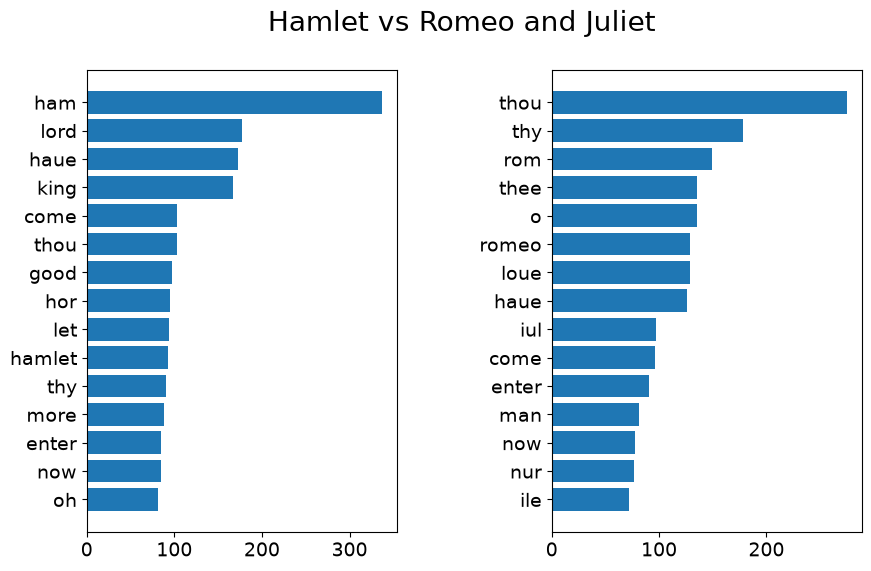

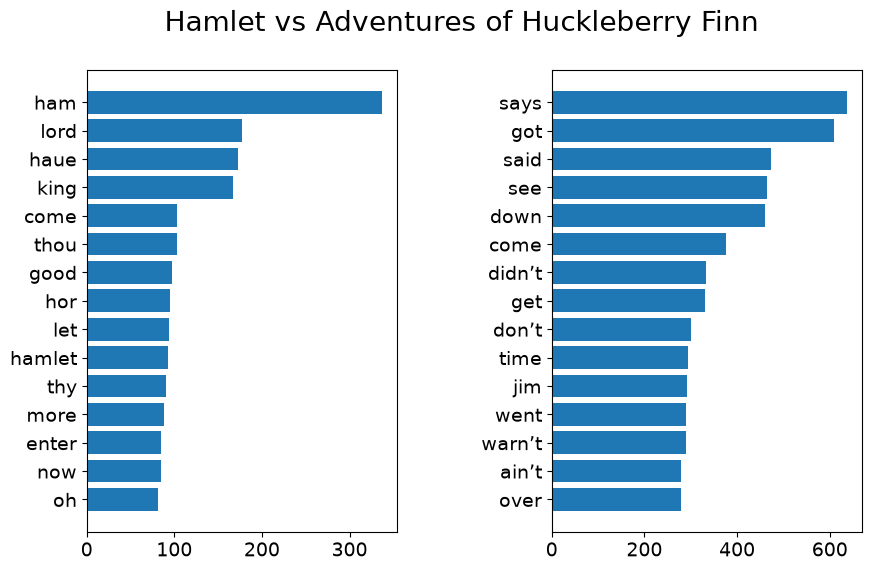

In [1]:
import requests, re, operator
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# remove special characters from each word
def cleanWord(w):
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    return re.sub('^[0-9\.]*$', "", wn)

# function to get frequency of each word and sort by frequency
def get_wf(book):
    t = book.lower()
    # split string into array of words
    wds = re.split('\s+',t)
    #clean words from any punctuation
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])

    # remove stop words from the list
    stop_words = {
        'the', 'and', 'of', 'to', 'a', 'in', 'that', 'is', 'it',
        'for', 'on', 'with', 'as', 'this', 'be', 'but', 'not',
        'at', 'by', 'from', 'or', 'are', 'was', 'were', 'an',
        'so', 'all', 'would', 'when', 'she', 'he', 'his', 'her',
        'they', 'them', 'their', 'there', 'then', 'these', 'those',
        'i', 'me', 'my', 'we', 'us', 'our', 'you', 'your',
        'do', 'does', 'did', 'have', 'has', 'had', 'can', 'could',
        'will', 'shall', 'should', 'may', 'might', 'must',
        'who', 'whom', 'which', 'what', 'where', 'why', 'how',
        'am', 'were', 'been', 'being','if', 'him', 'no', 'about',
        'one', 'up', 'out'
    }
    wds = [w for w in wds if w not in stop_words]
    # count frequency of each word
    wf = Counter(wds)

    # get list of words sorted by frequency
    wfs = sorted (wf.items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)
    return (wfs[0:ml][::-1])

# function to plot word frequency from two different books
def plotTwoLists(wf1, wf2, title):
    f = plt.figure(figsize=(10, 6))
    f.suptitle(title, fontsize=20)

    ax1 = f.add_subplot(121)
    plt.subplots_adjust(wspace=.5)

    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax1.set_yticks(range(len(wf1)))
    ax1.set_yticklabels([x[0] for x in wf1])
    ax1.barh(range(len(wf1)), [x[1] for x in wf1], align='center')

    ax2 = f.add_subplot(122)

    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.set_yticks(range(len(wf2)))
    ax2.set_yticklabels([x[0] for x in wf2])
    ax2.barh(range(len(wf2)), [x[1] for x in wf2], align='center')

    plt.show()
# Get text from gutenberg
hamlet = requests.get('https://www.gutenberg.org/ebooks/2265.txt.utf-8').text
romeo = requests.get('https://www.gutenberg.org/ebooks/1112.txt.utf-8').text
huckFinn = requests.get('https://www.gutenberg.org/ebooks/76.txt.utf-8').text

# Split original text from header and footer
hamlet = hamlet.split('=====================================================================')[1]
hamlet = hamlet.split('*** END OF THE PROJECT GUTENBERG EBOOK HAMLET ***')[0]
romeo = romeo.split('=====================================================================')[1]
romeo = romeo.split('*** END OF THE PROJECT GUTENBERG EBOOK ROMEO AND JULIET ***')[0]
huckFinn = huckFinn.split('Scene: The Mississippi Valley Time: Forty to fifty years ago')[1]
huckFinn = huckFinn.split('*** END OF THE PROJECT GUTENBERG EBOOK ADVENTURES OF HUCKLEBERRY FINN ***')[0]

# get word frequency for each book
wf_hamlet = get_wf(hamlet)
wf_romeo = get_wf(romeo)
wf_huckFinn = get_wf(huckFinn)

# plot comparisons
plotTwoLists(wf_hamlet,wf_romeo,'Hamlet vs Romeo and Juliet')
plotTwoLists(wf_hamlet, wf_huckFinn, 'Hamlet vs Adventures of Huckleberry Finn')